In [1]:
import sys
from pathlib import Path
sys.path[:0] = [str(Path.cwd().parent)]

import numpy as np
import matplotlib.pyplot as plt

from scripts.Hamiltonian import Hamiltonian
from scripts.Lattice import Lattice
from scripts.self_consistency import bdg_sc

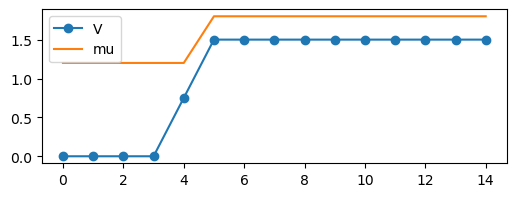

In [2]:
widthN = 5
widthP = 10

X, Y = widthN+widthP, 100
lattice = Lattice(X, Y)
t = 1
T=0.001

muN = 1.2 * t
muP = 1.8 * t
mu = np.zeros(lattice.X)
mu[:widthN] = muN
mu[widthN:] = muP

U = None
V_prime = None

V0 = 1.5 * t
V = V0 * np.ones(lattice.X)
V[:widthN] = 0
V[widthN-1] = V0/2

plt.figure(figsize=(6,2))
if U is not None:
    plt.plot(U, '-o', label="U")
if V is not None:
    plt.plot(V, '-o', label="V")
if V_prime is not None:
    plt.plot(V_prime, '-o', label="V'",)
plt.plot(mu, label='mu')
plt.legend()

In [3]:
H = Hamiltonian(t, mu, lattice,
                U=U, V_prime=V_prime, g_t=V,# g_s=V,
                F_init=[0.1, -0.1, 0.1j, -0.1j])

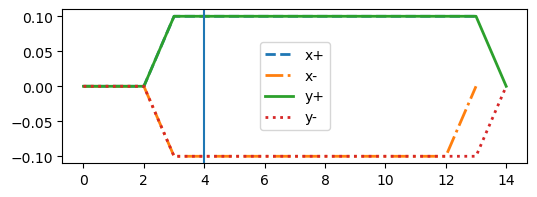

In [4]:
plt.figure(figsize=(6,2))
if U is not None:
    plt.plot(H.F0, label="F0")
if V is not None:
    plt.plot(np.real(H.F_xplus), label="x+", linestyle='--', lw=2)
    plt.plot(np.real(H.F_xmin), label="x-", linestyle='-.', lw=2)
    plt.plot(np.imag(H.F_yplus), label="y+", linestyle='-', lw=2)
    plt.plot(np.imag(H.F_ymin), label="y-", linestyle=':', lw=2)
if V_prime is not None:
    plt.plot(np.real(H.Fuu_xplus), label="x+", linestyle='--', lw=2)
    plt.plot(np.real(H.Fuu_xmin), label="x-", linestyle='-.', lw=2)
    plt.plot(np.imag(H.Fuu_yplus), label="y+", linestyle='-', lw=2)
    plt.plot(np.imag(H.Fuu_ymin), label="y-", linestyle=':', lw=2)
plt.legend()
plt.axvline(widthN-1)

In [5]:
F_swave, F_dwave, F_px, F_py = bdg_sc(H, atol=1e-4, rtol=1e-2, maxiter=1000, verbose=False, temperature=T)


Converged after 55 iterations


In [6]:
F, Fuu, Fdd = H.get_correlations()

F_px2 = F.px 
F_py2 = F.py 

T=0.001t


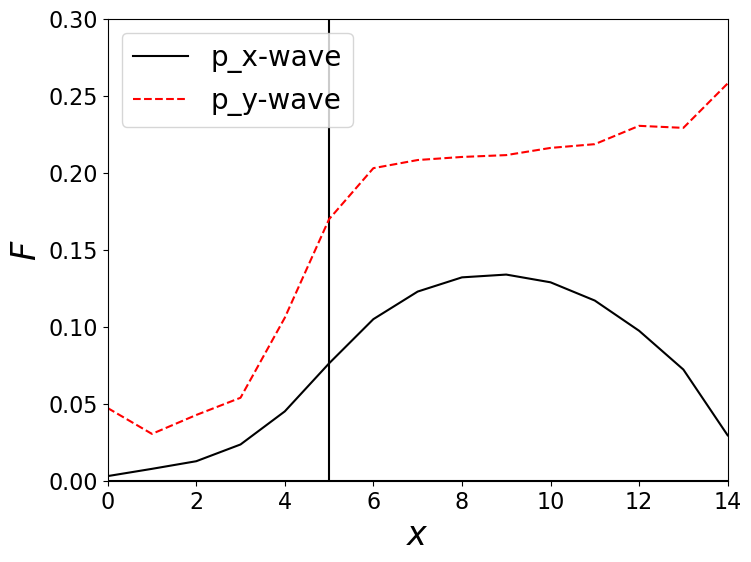

In [7]:
print(f"T={T}t")
x = np.arange(0, widthN + widthP)

fig, axs = plt.subplots(1, 1, figsize=(8, 6))
axs.axhline(0, color = 'black')
axs.axvline(widthN, color='black', linestyle='-')
axs.plot(x, np.real(F_px), label="p_x-wave", color='black')
axs.plot(x, np.imag(F_py), "--", label="p_y-wave", color='red')
axs.set_xlabel(r"$x$", fontsize=24)
axs.set_ylabel(r"$F$", fontsize=24)

axs.set_xlim(0, 14)
axs.set_ylim(0, 0.3)
axs.legend(fontsize=20)
axs.tick_params(labelsize=16)
plt.savefig('../figures/NP.svg')
plt.show()

In [8]:
from scripts.utils import is_hermitian 

In [9]:
print(is_hermitian(H.build_H_kindep()))
print(is_hermitian(H.build_H_k0()))
print(is_hermitian(H.build_H_k(np.pi/3)))

True
True
True


In [10]:
widthN = 5
widthP = 10

X, Y = widthN+widthP, 200
lattice = Lattice(X, Y)
t = 1
muN = 1.2 * t
muP = 1.8 * t
mu = np.zeros(lattice.X)
mu[:widthN] = muN
mu[widthN:] = muP

U = None
V_prime = None

V0 = 1.5 * t
V = V0 * np.ones(lattice.X)
V[:widthN] = 0
V[widthN] = V0/2

temp = 0.3

H = Hamiltonian(
    t, mu, lattice,
    U=U, V_prime=V_prime, V=V,
    F_init=[0.1, -0.1, 0.1j, -0.1j]
)

# Adjust to your actual bdg_sc output
F_swave, F_dwave, F_px, F_py = bdg_sc(
    H, maxiter=10000, temperature=temp,
    rtol=0.01, atol=1e-6
)

TypeError: Hamiltonian.__init__() got an unexpected keyword argument 'V'

(1.2549720035916377e-13+0j)
0.12863106319412457j


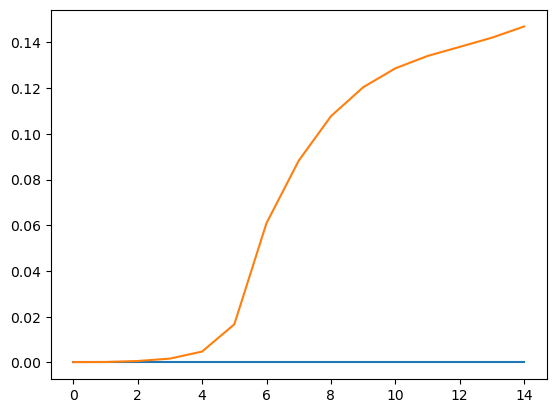

In [ ]:
plt.plot(np.real(F_px))
plt.plot(np.imag(F_py))

print(F_px[int(widthN+widthP/2)])
print(F_py[int(widthN+widthP/2)])


In [ ]:
# from joblib import Parallel, delayed
# from tqdm.auto import tqdm
# import copy

In [ ]:
# widthN = 5
# widthP = 10

# X, Y = widthN+widthP, 50
# lattice = Lattice(X, Y)
# t = 1

# muN = 1.2 * t
# muP = 1.8 * t
# mu = np.zeros(lattice.X)
# mu[:widthN] = muN
# mu[widthN:] = muP

# U = None
# V_prime = None

# V0 = 1.5 * t
# V = V0 * np.ones(lattice.X)
# V[:widthN] = 0 
# V[widthN-1] = V0/2

# plt.figure(figsize=(6,2))
# if U is not None:
#     plt.plot(U, '-o', label="U")
# if V is not None:
#     plt.plot(V, '-o', label="V")
# if V_prime is not None:
#     plt.plot(V_prime, '-o', label="V'",)
# plt.plot(mu, label='mu')
# plt.legend()

In [ ]:
# H = Hamiltonian(t, mu, lattice, U=U, V_prime=V_prime, V=V,
#                 F_init=[0.1, -0.1, 0.1j, -0.1j])

In [ ]:
T_list = np.concatenate([
    np.arange(0.001, 0.009 + 1e-12, 0.001),
    np.arange(0.01, 0.20 + 1e-12, 0.01),
    np.arange(0.21, 0.31 + 1e-12, 0.001),
    np.arange(0.32, 0.40 + 1e-12, 0.002)
])
print(len(T_list))

171


In [ ]:
# H = Hamiltonian(t, mu, lattice, U=U, V_prime=V_prime, V=V,
#                 F_init=[0.01, -0.01, 0.01j, -0.01j])

# def run_T(T):
#     H_local = copy.deepcopy(H)
#     F_swave, F_dwave, F_px, F_py = bdg_sc(
#         H_local, rtol=0.1, atol=1e-3, maxiter=10000, verbose=False, temperature=T
#     )
#     return (
#         F_px[int(widthN+widthP/2)],
#         F_py[int(widthN+widthP/2)],
#         F_swave[int(widthN+widthP/2)],
#         F_dwave[int(widthN+widthP/2)],
#     )

# results = Parallel(n_jobs=-1)(
#     delayed(run_T)(T) for T in tqdm(T_list)
# )

# F_px_arr, F_py_arr, F_swave_arr, F_dwave_arr = map(np.array, zip(*results))

In [ ]:
# print(int(widthN+widthP/2))
# print(F_px[int(30+35/2)])

In [ ]:
# plt.figure(figsize=(6,5))
# plt.clf()
# plt.plot(T_list, np.real(F_px_arr), linewidth=1, label=r"$p_x$-wave")
# plt.plot(T_list, np.abs(F_dwave_arr), linewidth=1, label=r"$d$-wave")
# plt.plot(T_list, np.abs(F_swave_arr), linewidth=1, label=r"$s$-wave")

# plt.plot(T_list, np.imag(F_py_arr), "--", linewidth=1, label=r"$p_y$-wave")
# plt.ylim(0,0.25)
# plt.xlim(0,0.6)
# plt.xlabel("T", fontsize=15)
# plt.legend(loc="best", fontsize=12)
# plt.tight_layout()
# plt.show()
